Saving spam.csv to spam (1).csv
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Accuracy: 0.9659192825112107
Precision: 1.0
Recall: 0.7466666666666667
F1 Score: 0.8549618320610687


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


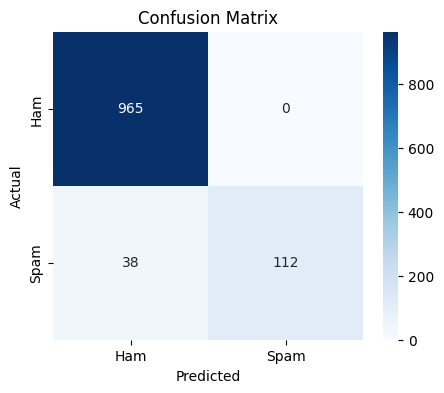

In [2]:
# ==========================================
# Name    : Navithanjali.M.S
# Roll no : 24BAD077
# SCENARIO 1 – MULTINOMIAL NAÏVE BAYES
# SMS Spam Classification (Google Colab)
# ==========================================

#  Upload Dataset in Google Colab
from google.colab import files
uploaded = files.upload()

#  Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Load Dataset
# Make sure your file name is spam.csv
df = pd.read_csv("spam.csv", encoding='latin-1')

# Keep only needed columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

#  Text Cleaning
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                         # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)         # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)

# Convert Text to TF-IDF Features
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_message'])

#  Encode Labels (ham=0, spam=1)
df['label'] = df['label'].map({'ham':0, 'spam':1})
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#  Train Model (Laplace smoothing alpha=1)
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

#  Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Saving spam.csv to spam (2).csv
First 5 rows of dataset:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 n

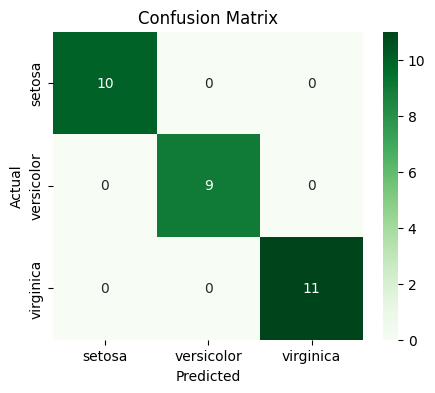

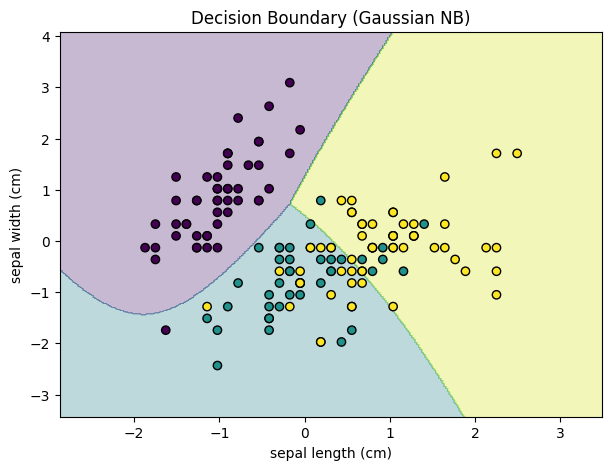

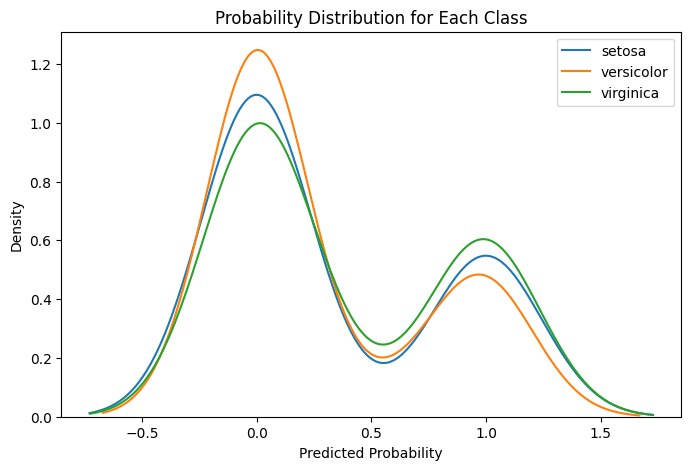

In [3]:
from google.colab import files
uploaded = files.upload()
# ==========================================
# Name    : Navithanjali.M.S
# Roll no : 24BAD077
# SCENARIO 2 – GAUSSIAN NAÏVE BAYES
# Name: Your Name
# Roll No: Your Roll Number
# ==========================================

#  Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#  Load Iris Dataset
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Convert to DataFrame (for inspection)
df = pd.DataFrame(X, columns=feature_names)
df['Species'] = y

print("First 5 rows of dataset:\n")
print(df.head())

#  Data Inspection
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

#  Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

#  Train Gaussian Naïve Bayes Model
model = GaussianNB()
model.fit(X_train, y_train)

#  Predict
y_pred = model.predict(X_test)

#  Evaluation Metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Decision Boundary Plot (Using 2 Features)
# We use only first two features for visualization

X_two = X_scaled[:, :2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y, test_size=0.2, random_state=42)

model2 = GaussianNB()
model2.fit(X_train2, y_train2)

# Create mesh grid
x_min, x_max = X_two[:, 0].min() - 1, X_two[:, 0].max() + 1
y_min, y_max = X_two[:, 1].min() - 1, X_two[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_two[:, 0], X_two[:, 1], c=y, edgecolor='k')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Decision Boundary (Gaussian NB)")
plt.show()

#  Probability Distribution Plot
probs = model.predict_proba(X_test)

plt.figure(figsize=(8,5))
for i in range(len(class_names)):
    sns.kdeplot(probs[:, i], label=class_names[i])

plt.title("Probability Distribution for Each Class")
plt.xlabel("Predicted Probability")
plt.legend()
plt.show()
